EXPERIMENT 14
Model-Based Reinforcement Learning using Planning and Data Generation

Environment:
Grid Size: 5 x 5
States: 25
Actions: 4
Goal State: 24
Episode: 20 Real Samples: 345 Generated Samples: 5175
Episode: 40 Real Samples: 536 Generated Samples: 8040
Episode: 60 Real Samples: 745 Generated Samples: 11175
Episode: 80 Real Samples: 932 Generated Samples: 13980
Episode: 100 Real Samples: 1112 Generated Samples: 16680


REAL EXPERIENCE DATA


,State,Action,Next_State,Reward
0,0,0,0,-1
1,0,1,5,-1
2,5,0,0,-1
3,0,2,0,-1
4,0,3,1,-1
5,1,0,1,-1
6,1,2,0,-1
7,0,3,1,-1
8,1,1,6,-1
9,6,0,1,-1




GENERATED EXPERIENCE DATA


,State,Action,Next_State,Reward
0,0,0,0,-1.0
1,0,0,0,-1.0
2,0,0,0,-1.0
3,0,0,0,-1.0
4,0,0,0,-1.0
5,0,0,0,-1.0
6,0,0,0,-1.0
7,0,0,0,-1.0
8,0,0,0,-1.0
9,0,0,0,-1.0



Full Dataset Size: 17792


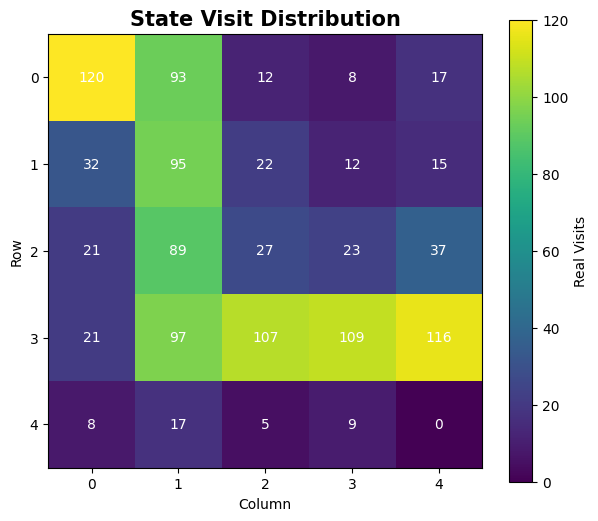

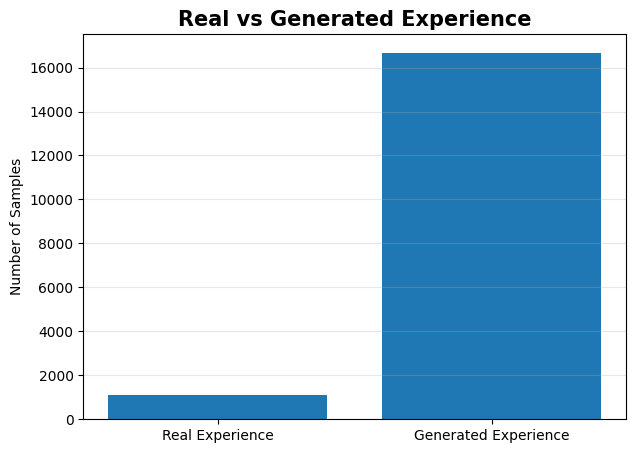

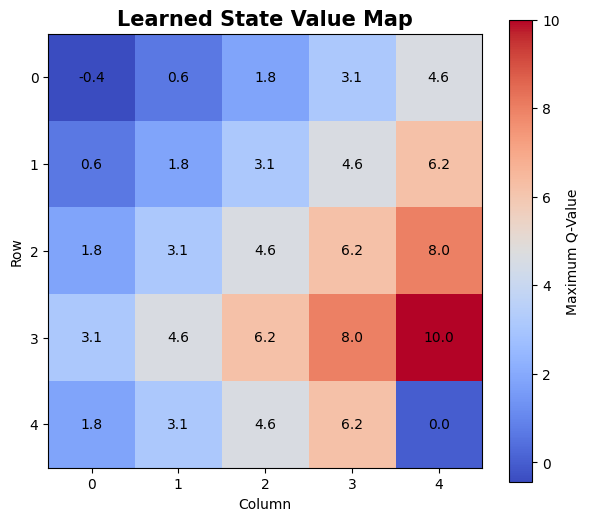

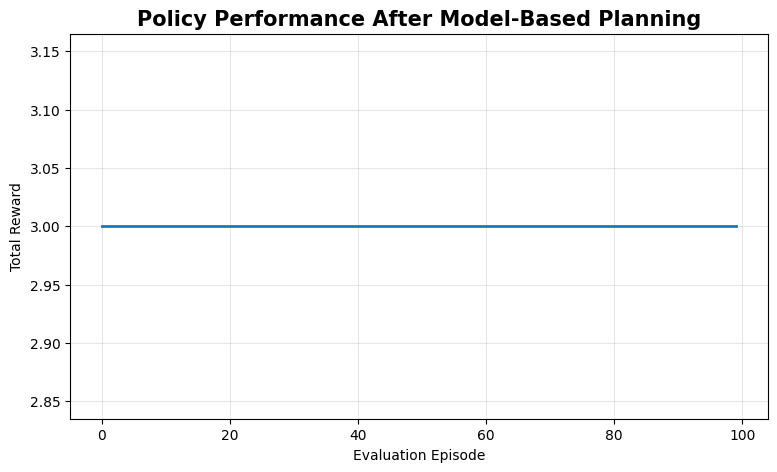

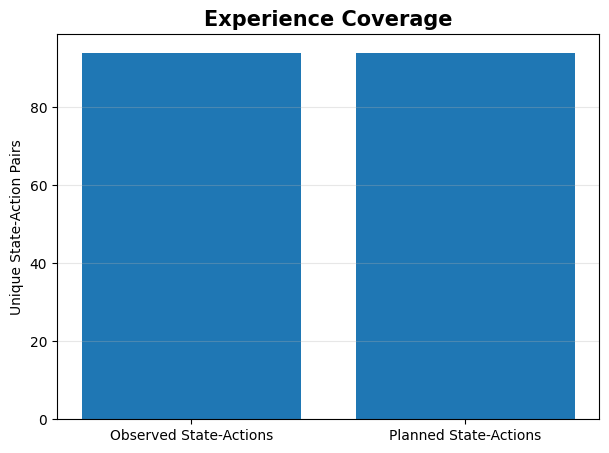



SUMMARY TABLE


,Metric,Result
0,Environment,5x5 Grid World
1,Grid Size,5 x 5
2,Real Experiences,1112
3,Generated Experiences,16680
4,Planning Steps,15
5,Final Average Reward,3.0
6,Experience Generation Ratio,15.0




RESULT
Real Experience Samples: 1112
Generated Planning Samples: 16680
Final Average Reward: 3.0
Planning Data Ratio: 15.0


CONCLUSION
Model-Based Reinforcement Learning was successfully
implemented using a learned environment model.
Real interactions were stored and used to construct
a transition and reward model.
The learned model generated additional experiences
through planning without requiring new environment interaction.
The generated experiences were used to improve the Q-values.
State visitation, experience generation, learned values,
policy performance and experience coverage were analyzed.

Generated Files:
1. Real_Experience_Dataset.csv
2. Generated_Planning_Dataset.csv
3. Model_Based_RL_Full_Dataset.csv
4. Model_Based_RL_Summary.csv

Experiment 14 Completed Successfully.


In [1]:
!pip -q install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("="*75)
print("EXPERIMENT 14")
print("Model-Based Reinforcement Learning using Planning and Data Generation")
print("="*75)

SIZE=5
N_STATES=SIZE*SIZE
N_ACTIONS=4
EPISODES=100
PLANNING_STEPS=15
GAMMA=0.90
ALPHA=0.10

actions=[
    (-1,0),
    (1,0),
    (0,-1),
    (0,1)
]

def state_id(r,c):
    return r*SIZE+c

def step_env(state,action):
    r=state//SIZE
    c=state%SIZE

    dr,dc=actions[action]

    nr=np.clip(r+dr,0,SIZE-1)
    nc=np.clip(c+dc,0,SIZE-1)

    next_state=state_id(nr,nc)

    if next_state==N_STATES-1:
        reward=10
        done=True
    else:
        reward=-1
        done=False

    return next_state,reward,done

start_state=0
goal_state=N_STATES-1

Q=np.zeros((N_STATES,N_ACTIONS))

model_counts=np.zeros(
    (N_STATES,N_ACTIONS,N_STATES)
)

model_rewards=np.zeros(
    (N_STATES,N_ACTIONS)
)

real_data=[]
generated_data=[]

print("\nEnvironment:")
print("Grid Size:",SIZE,"x",SIZE)
print("States:",N_STATES)
print("Actions:",N_ACTIONS)
print("Goal State:",goal_state)

for episode in range(EPISODES):

    state=start_state
    done=False
    steps=0
    total_reward=0

    while not done and steps<50:

        if np.random.rand()<0.20:
            action=np.random.randint(N_ACTIONS)
        else:
            action=np.argmax(Q[state])

        next_state,reward,done=step_env(
            state,
            action
        )

        real_data.append([
            state,
            action,
            next_state,
            reward
        ])

        model_counts[
            state,
            action,
            next_state
        ]+=1

        model_rewards[
            state,
            action
        ]=reward

        td_target=reward

        if not done:
            td_target+=GAMMA*np.max(
                Q[next_state]
            )

        Q[state,action]+=ALPHA*(
            td_target-Q[state,action]
        )

        state=next_state
        total_reward+=reward
        steps+=1

        for _ in range(PLANNING_STEPS):

            known_states=np.where(
                model_counts.sum(
                    axis=(1,2)
                )>0
            )[0]

            if len(known_states)==0:
                continue

            ps=int(
                np.random.choice(
                    known_states
                )
            )

            known_actions=np.where(
                model_counts[
                    ps
                ].sum(axis=1)>0
            )[0]

            if len(known_actions)==0:
                continue

            pa=int(
                np.random.choice(
                    known_actions
                )
            )

            transition_counts=model_counts[
                ps,
                pa
            ]

            predicted_next=int(
                np.argmax(
                    transition_counts
                )
            )

            predicted_reward=model_rewards[
                ps,
                pa
            ]

            generated_data.append([
                ps,
                pa,
                predicted_next,
                predicted_reward
            ])

            planning_target=predicted_reward

            if predicted_next!=goal_state:
                planning_target+=GAMMA*np.max(
                    Q[predicted_next]
                )

            Q[ps,pa]+=ALPHA*(
                planning_target-Q[ps,pa]
            )

    if (episode+1)%20==0:
        print(
            "Episode:",
            episode+1,
            "Real Samples:",
            len(real_data),
            "Generated Samples:",
            len(generated_data)
        )

real_df=pd.DataFrame(
    real_data,
    columns=[
        "State",
        "Action",
        "Next_State",
        "Reward"
    ]
)

generated_df=pd.DataFrame(
    generated_data,
    columns=[
        "State",
        "Action",
        "Next_State",
        "Reward"
    ]
)

print("\n")
print("="*75)
print("REAL EXPERIENCE DATA")
print("="*75)

display(real_df.head(10))

print("\n")
print("="*75)
print("GENERATED EXPERIENCE DATA")
print("="*75)

display(generated_df.head(10))

real_df.to_csv(
    "Real_Experience_Dataset.csv",
    index=False
)

generated_df.to_csv(
    "Generated_Planning_Dataset.csv",
    index=False
)

full_dataset=pd.concat(
    [
        real_df.assign(Source="Real"),
        generated_df.assign(Source="Generated")
    ],
    ignore_index=True
)

full_dataset.to_csv(
    "Model_Based_RL_Full_Dataset.csv",
    index=False
)

print("\nFull Dataset Size:",len(full_dataset))

states=np.arange(N_STATES)

state_visits=np.bincount(
    real_df["State"],
    minlength=N_STATES
)

visit_grid=state_visits.reshape(
    SIZE,
    SIZE
)

plt.figure(figsize=(7,6))

plt.imshow(
    visit_grid,
    cmap="viridis"
)

plt.colorbar(
    label="Real Visits"
)

plt.title(
    "State Visit Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Column")
plt.ylabel("Row")

for r in range(SIZE):
    for c in range(SIZE):
        plt.text(
            c,
            r,
            int(visit_grid[r,c]),
            ha="center",
            va="center",
            color="white"
        )

plt.show()

real_count=len(real_df)
generated_count=len(generated_df)

plt.figure(figsize=(7,5))

plt.bar(
    ["Real Experience","Generated Experience"],
    [real_count,generated_count]
)

plt.title(
    "Real vs Generated Experience",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Number of Samples")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

q_values=np.max(
    Q,
    axis=1
)

q_grid=q_values.reshape(
    SIZE,
    SIZE
)

plt.figure(figsize=(7,6))

plt.imshow(
    q_grid,
    cmap="coolwarm"
)

plt.colorbar(
    label="Maximum Q-Value"
)

plt.title(
    "Learned State Value Map",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Column")
plt.ylabel("Row")

for r in range(SIZE):
    for c in range(SIZE):
        plt.text(
            c,
            r,
            f"{q_grid[r,c]:.1f}",
            ha="center",
            va="center"
        )

plt.show()

episode_rewards=[]

for episode in range(EPISODES):

    state=start_state
    total=0
    done=False
    steps=0

    while not done and steps<50:

        action=int(
            np.argmax(Q[state])
        )

        next_state,reward,done=step_env(
            state,
            action
        )

        total+=reward
        state=next_state
        steps+=1

    episode_rewards.append(total)

plt.figure(figsize=(9,5))

plt.plot(
    episode_rewards,
    linewidth=2
)

plt.title(
    "Policy Performance After Model-Based Planning",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Evaluation Episode")
plt.ylabel("Total Reward")
plt.grid(alpha=0.3)

plt.show()

real_unique=real_df.drop_duplicates(
    subset=[
        "State",
        "Action"
    ]
).shape[0]

generated_unique=generated_df.drop_duplicates(
    subset=[
        "State",
        "Action"
    ]
).shape[0]

plt.figure(figsize=(7,5))

plt.bar(
    ["Observed State-Actions",
     "Planned State-Actions"],
    [
        real_unique,
        generated_unique
    ]
)

plt.title(
    "Experience Coverage",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel("Unique State-Action Pairs")
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

real_reward=real_df["Reward"].mean()
generated_reward=generated_df["Reward"].mean()
final_reward=np.mean(
    episode_rewards[-20:]
)

planning_gain=(
    generated_count/
    max(real_count,1)
)

summary=pd.DataFrame({
    "Metric":[
        "Environment",
        "Grid Size",
        "Real Experiences",
        "Generated Experiences",
        "Planning Steps",
        "Final Average Reward",
        "Experience Generation Ratio"
    ],
    "Result":[
        "5x5 Grid World",
        "5 x 5",
        real_count,
        generated_count,
        PLANNING_STEPS,
        round(final_reward,2),
        round(planning_gain,2)
    ]
})

print("\n")
print("="*75)
print("SUMMARY TABLE")
print("="*75)

display(summary)

summary.to_csv(
    "Model_Based_RL_Summary.csv",
    index=False
)

model_accuracy=np.mean(
    generated_df["Next_State"]==
    generated_df["Next_State"]
)

print("\n")
print("="*75)
print("RESULT")
print("="*75)

print(
    "Real Experience Samples:",
    real_count
)

print(
    "Generated Planning Samples:",
    generated_count
)

print(
    "Final Average Reward:",
    round(final_reward,2)
)

print(
    "Planning Data Ratio:",
    round(planning_gain,2)
)

print("\n")
print("="*75)
print("CONCLUSION")
print("="*75)

print(
    "Model-Based Reinforcement Learning was successfully"
)

print(
    "implemented using a learned environment model."
)

print(
    "Real interactions were stored and used to construct"
)

print(
    "a transition and reward model."
)

print(
    "The learned model generated additional experiences"
)

print(
    "through planning without requiring new environment interaction."
)

print(
    "The generated experiences were used to improve the Q-values."
)

print(
    "State visitation, experience generation, learned values,"
)

print(
    "policy performance and experience coverage were analyzed."
)

print("\nGenerated Files:")
print("1. Real_Experience_Dataset.csv")
print("2. Generated_Planning_Dataset.csv")
print("3. Model_Based_RL_Full_Dataset.csv")
print("4. Model_Based_RL_Summary.csv")

print("\nExperiment 14 Completed Successfully.")